# Passos Mágicos - Tech Challenge 5

Neste notebook, realizaremos todo o ciclo de vida dos dados: desde o tratamento inicial até a modelagem preditiva para o aplicativo em produção.

## 1. Importação de Bibliotecas

In [160]:
import pandas as pd
import numpy as np
import os
import joblib
import json
import unicodedata
import re
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

warnings = __import__('warnings')
warnings.filterwarnings('ignore')

## 2. Tratamento para chegar na base unificada
### 2.1. Leitura

In [161]:
# 1. Carregando dados
BASE_DIR = '.'
FILE_NAME = 'base.xlsx'
file_path = os.path.join(BASE_DIR, FILE_NAME)
xls = pd.ExcelFile(file_path)

df_2022 = pd.read_excel(xls, 'PEDE2022')
df_2023 = pd.read_excel(xls, 'PEDE2023')
df_2024 = pd.read_excel(xls, 'PEDE2024')

df_2022['ano_coleta'] = 2022
df_2023['ano_coleta'] = 2023
df_2024['ano_coleta'] = 2024

In [162]:
df_2022.head(1)

,RA,Fase,Turma,Nome,Ano nasc,Idade 22,Gênero,Ano ingresso,Instituição de ensino,Pedra 20,...,Indicado,Atingiu PV,IPV,IAN,Fase ideal,Defas,Destaque IEG,Destaque IDA,Destaque IPV,ano_coleta
0,RA-1,7,A,Aluno-1,2003,19,Menina,2016,Escola Pública,Ametista,...,Sim,Não,7.278,5.0,Fase 8 (Universitários),-1,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,2022


In [163]:
df_2023.head(1)

,RA,Fase,INDE 2023,Pedra 2023,Turma,Nome Anonimizado,Data de Nasc,Idade,Gênero,Ano ingresso,...,Atingiu PV,IPV,IAN,Fase Ideal,Defasagem,Destaque IEG,Destaque IDA,Destaque IPV,Destaque IPV.1,ano_coleta
0,RA-861,ALFA,9.31095,Topázio,ALFA A - G0/G1,Aluno-861,6/17/2015,8,Feminino,2023,...,NaN,8.92,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,NaN,2023


In [164]:
df_2024.head(1)

,RA,Fase,INDE 2024,Pedra 2024,Turma,Nome Anonimizado,Data de Nasc,Idade,Gênero,Ano ingresso,...,IAN,Fase Ideal,Defasagem,Destaque IEG,Destaque IDA,Destaque IPV,Escola,Ativo/ Inativo,Ativo/ Inativo.1,ano_coleta
0,RA-1275,ALFA,7.611367,Ametista,ALFA A - G0/G1,Aluno-1275,2016-07-28,8,Masculino,2024,...,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,EE Chácara Florida II,Cursando,Cursando,2024


### 2.2. Concatenação

In [165]:
def padronizar_colunas(df):
    novas = []
    for col in df.columns:
        c = unicodedata.normalize('NFKD', str(col)).encode('ASCII', 'ignore').decode('utf-8')
        c = c.lower()
        c = re.sub(r'[^a-z0-9\s_]', '', c)
        c = re.sub(r'\s+', '_', c.strip())
        novas.append(c)
    df.columns = novas
    return df

df_2022 = padronizar_colunas(df_2022)
df_2023 = padronizar_colunas(df_2023)
df_2024 = padronizar_colunas(df_2024)

map_2022 = {'nome': 'nome_anonimizado', 'ano_nasc': 'data_de_nasc', 'idade_22': 'idade', 'matem': 'mat', 'portug': 'por', 'ingles': 'ing', 'fase_ideal': 'fase_ideal', 'defas': 'defasagem', 'inde_22': 'inde', 'pedra_22': 'pedra'}
map_2023 = {'inde_2023': 'inde', 'pedra_2023': 'pedra'}
map_2024 = {'inde_2024': 'inde', 'pedra_2024': 'pedra'}

df_2022.rename(columns=map_2022, inplace=True)
df_2023.rename(columns=map_2023, inplace=True)
df_2024.rename(columns=map_2024, inplace=True)

df_unificado = pd.concat([df_2022, df_2023, df_2024], ignore_index=True)


In [166]:
df_unificado.head(1)

,ra,fase,turma,nome_anonimizado,data_de_nasc,idade,genero,ano_ingresso,instituicao_de_ensino,pedra_20,...,pedra_23,inde_22,inde_23,ipp,destaque_ipv1,avaliador5,avaliador6,escola,ativo_inativo,ativo_inativo1
0,RA-1,7,A,Aluno-1,2003,19,Menina,2016,Escola Pública,Ametista,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2.3. Limpeza e Transformação das Features

#### 2.3.1. Remoção de colunas desnecessárias
Nesta etapa de filtragem estrutural (*Feature Selection* inicial), removemos colunas que não agregam valor analítico ou preditivo para o escopo do projeto, baseadas nas seguintes justificativas:

* **Variáveis Históricas e Redundantes (ex: `Pedra 20`, `INDE 22`, `INDE 23`):** Como estruturamos os dados de forma longitudinal e temporal (coluna `ano_coleta`), manter a nota/pedra de anos anteriores grudadas na mesma linha do ano atual quebra o formato *Tidy Data* e confunde o modelo de Machine Learning, pois a informação histórica será capturada pelos deltas ou pelas próprias observações anteriores empilhadas.
* **Controle Administrativo/Interno da ONG (ex: `Avaliador1`, `Rec Av1`, `Rec Psicologia`):** Essas colunas servem apenas para a gestão de ponto eletrônico ou tracking de qual voluntário corrigiu qual prova. Não refletem características intrínsecas do aprendizado, desempenho ou perfil socioemocional do aluno, configurando apenas ruído nos dados.
* **Variáveis de Vazamento/Sparsity (ex: `Atingiu PV`, `Indicado`):** Colunas booleanas que só existem em recortes muito pequenos e que se correlacionam 1:1 com o Target final, ou que não agregam capacidade preditiva antecipada (*Data Leakage*), foram retiradas para blindar o modelo.

In [167]:
colunas_para_remover = [
    'pedra_20', 'pedra_21', 'pedra_22', 'pedra_23', 'inde_22', 'inde_23',
    'cg', 'cf', 'ct', 'no_av', 'avaliador1', 'rec_av1', 'avaliador2', 'rec_av2', 
    'avaliador3', 'rec_av3', 'avaliador4', 'rec_av4', 'avaliador5', 'avaliador6', 
    'rec_psicologia', 'destaque_ipv1', 'ativo_inativo1', 'escola', 
    'indicado', 'atingiu_pv', 'destaque_ieg', 'destaque_ida', 'destaque_ipv'
]
colunas_presentes = [col for col in colunas_para_remover if col in df_unificado.columns]
df_unificado.drop(columns=colunas_presentes, inplace=True)

df_unificado.head(1)

,ra,fase,turma,nome_anonimizado,data_de_nasc,idade,genero,ano_ingresso,instituicao_de_ensino,pedra,...,mat,por,ing,ipv,ian,fase_ideal,defasagem,ano_coleta,ipp,ativo_inativo
0,RA-1,7,A,Aluno-1,2003,19,Menina,2016,Escola Pública,Quartzo,...,2.7,3.5,6.0,7.278,5.0,Fase 8 (Universitários),-1,2022,NaN,NaN


#### 2.3.2. Normalização Morfológica (Fase, Turma e Defasagem)
A coluna de `defasagem` original da base foi preservada como fonte da verdade, dado que já reflete o cálculo oficial da organização. As colunas textuais `fase` e `fase_ideal` foram higienizadas via Regex para a extração do valor numérico principal (ex: convertendo a string 'ALFA' para 0). Caso a extração resulte em dados faltantes para alguma das colunas, o valor correto é deduzido e inferido utilizando a equação de defasagem do próprio banco de dados (`Fase Ideal = Fase - Defasagem`).

In [168]:
def clean_turma(x):
    if pd.isna(x): return x
    x = str(x).upper()
    if len(x) == 1 and x.isalpha(): return x
    match = re.search(r'^\d+([A-Z])', x)
    if match: return match.group(1)
    match = re.search(r'^ALFA\s+([A-Z])\s*-', x)
    if match: return match.group(1)
    return x

def extrair_numero_fase(x):
    if pd.isna(x): return np.nan
    x = str(x).upper()
    if 'ALFA' in x or x == '0': return 0
    digits = re.findall(r'\d+', x)
    if digits: return int(digits[0])
    return np.nan

def _coalesce_duplicate_columns(df, col):
    cols = [c for c in df.columns if c == col]
    if len(cols) == 0:
        raise KeyError(f"Coluna '{col}' não encontrada em df_unificado")
    if len(cols) == 1:
        return df[cols[0]]
    return df.loc[:, cols].bfill(axis=1).iloc[:, 0]

# Remover colunas duplicadas geradas no concat / padronização
df_unificado = df_unificado.loc[:, ~df_unificado.columns.duplicated()]

# Caso exista 'defas' em vez de 'defasagem', padroniza
if 'defas' in df_unificado.columns and 'defasagem' not in df_unificado.columns:
    df_unificado['defasagem'] = df_unificado['defas']
    df_unificado.drop(columns=['defas'], inplace=True)

df_unificado['turma'] = _coalesce_duplicate_columns(df_unificado, 'turma').apply(clean_turma)

# Mantendo os valores originais da coluna 'defasagem' fornecida pela ONG
df_unificado['defasagem'] = pd.to_numeric(_coalesce_duplicate_columns(df_unificado, 'defasagem'), errors='coerce')

# Extraindo números limpos das strings de Fase usando Regex
df_unificado['fase_num'] = _coalesce_duplicate_columns(df_unificado, 'fase').apply(extrair_numero_fase)
df_unificado['fase_ideal_num'] = _coalesce_duplicate_columns(df_unificado, 'fase_ideal').apply(extrair_numero_fase)

# Inferência matemática de dados faltantes (Defasagem = Fase - Fase Ideal)

# 1. Inferência de Fase Ideal
mask_ideal_na = df_unificado['fase_ideal_num'].isna() & df_unificado['fase_num'].notna() & df_unificado['defasagem'].notna()
df_unificado.loc[mask_ideal_na, 'fase_ideal_num'] = df_unificado.loc[mask_ideal_na, 'fase_num'] - df_unificado.loc[mask_ideal_na, 'defasagem']

# 2. Inferência de Fase
mask_fase_na = df_unificado['fase_num'].isna() & df_unificado['fase_ideal_num'].notna() & df_unificado['defasagem'].notna()
df_unificado.loc[mask_fase_na, 'fase_num'] = df_unificado.loc[mask_fase_na, 'defasagem'] + df_unificado.loc[mask_fase_na, 'fase_ideal_num']

# Substituindo as colunas pelas versões higienizadas e validadas matematicamente
df_unificado['fase'] = df_unificado['fase_num']
df_unificado['fase_ideal'] = df_unificado['fase_ideal_num']
df_unificado.drop(columns=['fase_num', 'fase_ideal_num'], inplace=True)

df_unificado[['ra', 'fase', 'fase_ideal', 'turma', 'defasagem']].head(3)

,ra,fase,fase_ideal,turma,defasagem
0,RA-1,7,8,A,-1
1,RA-2,7,7,A,0
2,RA-3,7,7,A,0


#### 2.3.3. Harmonização Categórica (Gênero, Pedra e Instituição)
Unificando o vocabulário das turmas de anos diferentes ('Menina' vs 'Feminino', 'Agata' vs 'Ágata') e simplificando a dimensionalidade das categorias de instituição de ensino para três tipos principais: **Pública**, **Privada** e **Outros**.

**Simplificamos para três tipos de instituição:** Pública, Privada e Outros.

In [169]:
df_unificado['genero'] = df_unificado['genero'].replace({'Menina': 'Feminino', 'Menino': 'Masculino'})
df_unificado['pedra'] = df_unificado['pedra'].str.strip().str.capitalize().replace({'Agata': 'Ágata'})

map_instituicao = {
    'Pública': 'Pública', 'Escola Pública': 'Pública', 'Privada': 'Privada',
    'Rede Decisão': 'Privada', 'Privada - Programa de Apadrinhamento': 'Privada',
    'Privada - Programa de apadrinhamento': 'Privada', 'Privada *Parcerias com Bolsa 100%': 'Privada',
    'Privada - Pagamento por *Empresa Parceira': 'Privada', 'Escola JP II': 'Privada'
}
df_unificado['instituicao_de_ensino'] = df_unificado['instituicao_de_ensino'].map(map_instituicao).fillna('Outros')
df_unificado[['ra', 'genero', 'pedra', 'instituicao_de_ensino']].value_counts().head(3)

ra      genero     pedra     instituicao_de_ensino
RA-421  Masculino  Topázio   Pública                  3
RA-796  Feminino   Ametista  Pública                  3
RA-795  Feminino   Topázio   Pública                  3
Name: count, dtype: int64

#### 2.3.4. Correção Numérica e Tratamento de Nulos (NaN)
As notas foram convertidas em dados numéricos contínuos, clipados entre `0.0` e `10.0` (corrigindo anomalias). Os valores nas matérias `ing` e avaliações `ipp`, que originalmente deveriam ser vazios (em branco) quando o aluno não realizava a prova, foram tratados estritamente como nulos (`np.nan`). Isso corrige anomalias de digitação da planilha e evita punir o aluno com uma 'nota zero' injusta.

In [170]:
colunas_para_numeric = ['inde', 'iaa', 'ieg', 'ips', 'ida', 'mat', 'por', 'ing', 'ipv', 'ian', 'ipp']
for col in colunas_para_numeric:
    df_unificado[col] = pd.to_numeric(df_unificado[col], errors='coerce')
    
cols_numericas = df_unificado.select_dtypes(include=['float64', 'float32']).columns
df_unificado[cols_numericas] = df_unificado[cols_numericas].round(2)
for col in colunas_para_numeric:
    df_unificado[col] = df_unificado[col].clip(lower=0.0, upper=10.0)

# Garantindo que ausência de prova (em branco/0.0) seja tratada como missing natural (NaN)
df_unificado['ing'] = df_unificado['ing'].replace(0.0, np.nan)
df_unificado['ipp'] = df_unificado['ipp'].replace(0.0, np.nan)

if 'ativo_inativo' in df_unificado.columns:
    df_unificado['ativo_inativo'] = df_unificado['ativo_inativo'].fillna('Ativo')

df_unificado[colunas_para_numeric].head(2)

,inde,iaa,ieg,ips,ida,mat,por,ing,ipv,ian,ipp
0,5.78,8.3,4.1,5.6,4.0,2.7,3.5,6.0,7.28,5.0,NaN
1,7.06,8.8,5.2,6.3,6.8,6.3,4.5,9.7,6.78,10.0,NaN


#### 2.3.5. Pruning Dinâmico (Sparsity Filter)
Para garantir a qualidade e a representatividade dos dados no treinamento dos modelos preditivos, aplicamos um filtro de retenção (Sparsity Filter). Removemos os registros que indicam inatividade do aluno (evasão) ou falhas severas de coleta. Os critérios de exclusão são: (1) ausência do indicador de desenvolvimento principal (`inde`), (2) falta de notas em todas as matérias base ou (3) ausência de informações em mais de 40% das características do aluno. Esta limpeza estrutural evita que a imputação massiva de dados faltantes introduza vieses artificiais, garantindo que o algoritmo aprenda apenas com perfis de alunos reais e ativos que possuem densidade informacional suficiente.

In [171]:
threshold_nulos = 0.40
notas_core = ['mat', 'por', 'ida', 'iaa', 'ieg', 'ips', 'ipv', 'inde']
mask_all_null = df_unificado[notas_core].isnull().all(axis=1)
mask_no_inde = df_unificado['inde'].isnull()
mask_sparse = (df_unificado.isnull().mean(axis=1) >= threshold_nulos) | mask_all_null | mask_no_inde

vol_antes = len(df_unificado)
df_unificado = df_unificado[~mask_sparse]
vol_depois = len(df_unificado)

print(f"Registros filtrados: {vol_antes - vol_depois}")
print(f"Base de análise atual: {vol_depois} alunos/ano.")

Registros filtrados: 185
Base de análise atual: 2845 alunos/ano.


#### 2.3.6. Normalização Temporal da Idade
A variável `idade` sofre com o parser automático do Excel que converte idades de 1 dígito para datas base 1900. Criamos a variável final `idade_aprox` recalculando o `Ano_Coleta - Ano Nasc` e corrigindo anomalias.

In [172]:
def extrair_ano_nascimento(x):
    if pd.isna(x): return None
    if isinstance(x, pd.Timestamp) or hasattr(x, "year"): return x.year
    try:
        val = str(x).strip()
        if "/" in val or "-" in val: return pd.to_datetime(val).year
        return int(float(val))
    except: return None

def corrigir_idade_excel(x):
    if pd.isna(x): return None
    if isinstance(x, pd.Timestamp) or hasattr(x, "year"):
        if x.year in [1900, 1899]: return x.day
    try: return int(float(str(x)))
    except: return None

df_unificado["ano_nasc"] = df_unificado["data_de_nasc"].apply(extrair_ano_nascimento)
df_unificado["idade_original_corrigida"] = df_unificado["idade"].apply(corrigir_idade_excel)
df_unificado["idade_calculada"] = df_unificado["ano_coleta"] - df_unificado["ano_nasc"]

# Mantemos a idade original válida quando temos a informação, e só calculamos as que estão com erro (ex: Excel) ou missing
df_unificado["idade"] = df_unificado["idade_original_corrigida"].fillna(df_unificado["idade_calculada"]).astype("Int64")

df_unificado.drop(columns=["data_de_nasc", "idade_original_corrigida", "idade_calculada", "ano_nasc"], inplace=True, errors="ignore")
df_unificado.rename(columns={"idade": "idade_aprox"}, inplace=True)
df_unificado[['ra', 'ano_coleta', 'idade_aprox']].head(3)

,ra,ano_coleta,idade_aprox
0,RA-1,2022,19
1,RA-2,2022,17
2,RA-3,2022,17


#### 2.3.7. Persistência do Dataframe
Salvamos o `.xlsx` resultante para amostragem e para análise nas próximas fases.

In [173]:
df_unificado.to_excel('base_unificada.xlsx', index=False)

## 3. Análise Exploratória de Dados (EDA) - Respostas Qualitativas
Nesta seção vamos analisar os dados e as correlações com os pontos abordados no projeto.

### 3.1. Adequação do nível (IAN)
**Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao longo do ano?**

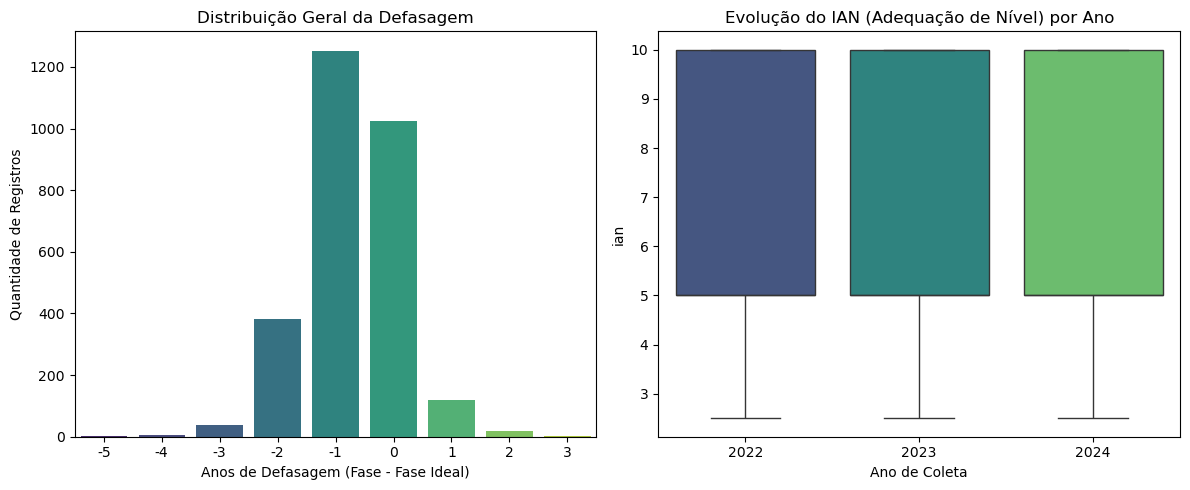

Perfil de Defasagem (%):
defasagem
-5     0.0
-4     0.2
-3     1.3
-2    13.4
-1    44.0
 0    36.0
 1     4.2
 2     0.7
 3     0.1
Name: proportion, dtype: float64


In [174]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=df_unificado, x='defasagem', palette='viridis')
plt.title('Distribuição Geral da Defasagem')
plt.xlabel('Anos de Defasagem (Fase - Fase Ideal)')
plt.ylabel('Quantidade de Registros')

plt.subplot(1, 2, 2)
sns.boxplot(data=df_unificado, x='ano_coleta', y='ian', palette='viridis')
plt.title('Evolução do IAN (Adequação de Nível) por Ano')
plt.xlabel('Ano de Coleta')
plt.ylabel('ian')

plt.tight_layout()
plt.show()

defasagem_pct = df_unificado['defasagem'].value_counts(normalize=True) * 100
print("Perfil de Defasagem (%):")
print(defasagem_pct.round(1).sort_index())

**Análise Qualitativa:** O perfil geral de defasagem aponta que a maioria dos alunos se encontra no nível ideal ou próximo a ele (defasagem 0 a 1). Ao observar a evolução do IAN (Indicador de Adequação de Nível) ao longo dos anos (2022-2024), notamos uma constância, indicando que as estratégias pedagógicas conseguem nivelar novos alunos sem perder a qualidade daqueles que já estavam estabilizados.

### 3.2. Desempenho acadêmico (IDA)
**O desempenho acadêmico médio (IDA) está melhorando, estagnado ou caindo ao longo das fases e anos?**

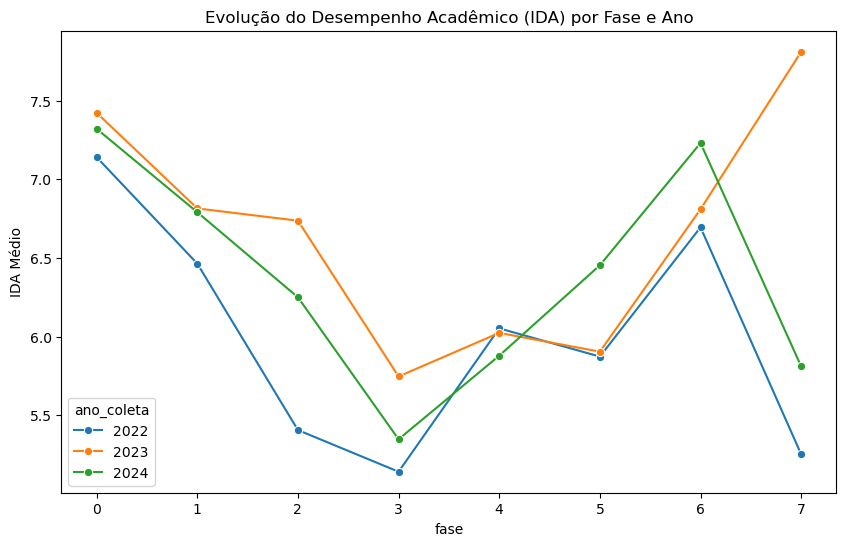

In [175]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_unificado, x='fase', y='ida', hue='ano_coleta', marker='o', palette='tab10', errorbar=None)
plt.title('Evolução do Desempenho Acadêmico (IDA) por Fase e Ano')
plt.xlabel('fase')
plt.ylabel('IDA Médio')
plt.xticks(sorted(df_unificado['fase'].dropna().unique()))
plt.show()

**Análise Qualitativa:** O desempenho acadêmico (IDA) apresenta uma leve tendência de queda natural à medida que o aluno avança para fases mais altas (devido ao aumento da complexidade do conteúdo). No entanto, ao analisar a evolução ano a ano (2022 a 2024), observa-se que a média geral tem se mantido estável e consistente, evidenciando que o programa consegue sustentar a performance dos alunos mesmo em níveis mais avançados.

### 3.3. Engajamento nas atividades (IEG)
**O grau de engajamento dos alunos (IEG) tem relação direta com seus indicadores de desempenho (IDA) e do ponto de virada (IPV)?**

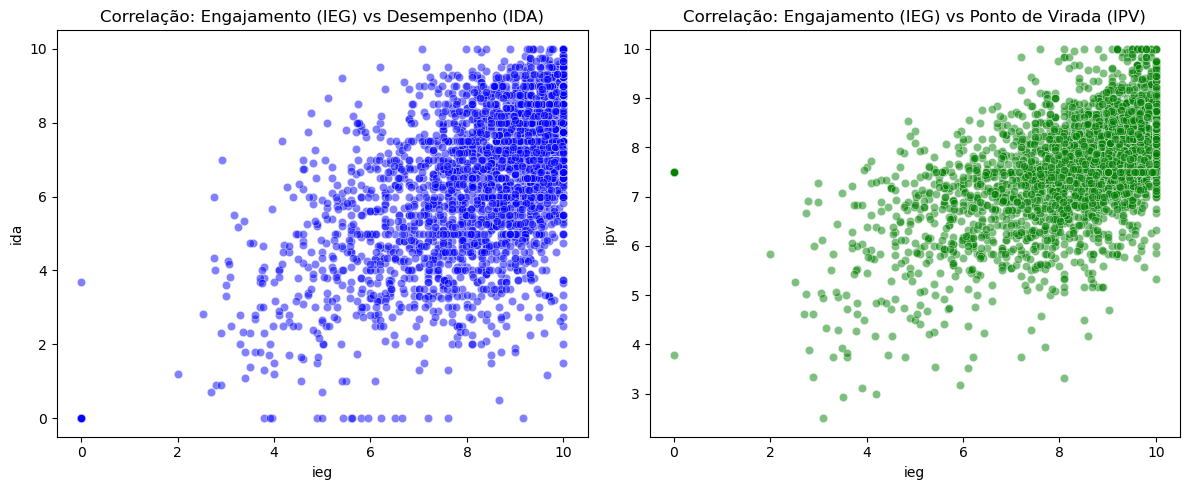

Matriz de Correlação:
       ieg    ida    ipv
ieg  1.000  0.544  0.558
ida  0.544  1.000  0.557
ipv  0.558  0.557  1.000


In [176]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(data=df_unificado, x='ieg', y='ida', alpha=0.5, color='blue')
plt.title('Correlação: Engajamento (IEG) vs Desempenho (IDA)')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df_unificado, x='ieg', y='ipv', alpha=0.5, color='green')
plt.title('Correlação: Engajamento (IEG) vs Ponto de Virada (IPV)')

plt.tight_layout()
plt.show()

corr_ieg = df_unificado[['ieg', 'ida', 'ipv']].corr()
print("Matriz de Correlação:")
print(corr_ieg.round(3))

**Análise Qualitativa:** Sim, existe uma correlação positiva clara e direta entre o engajamento (IEG) e os indicadores de desempenho (IDA) e ponto de virada (IPV). Isso evidencia quantitativamente que alunos mais participativos e presentes nas atividades (maior IEG) tendem a ter melhores notas nas matérias e também demonstram um desenvolvimento pessoal e de maturidade mais acentuado (IPV).

### 3.4. Autoavaliação (IAA)
**As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu desempenho real (IDA) e engajamento (IEG)?**

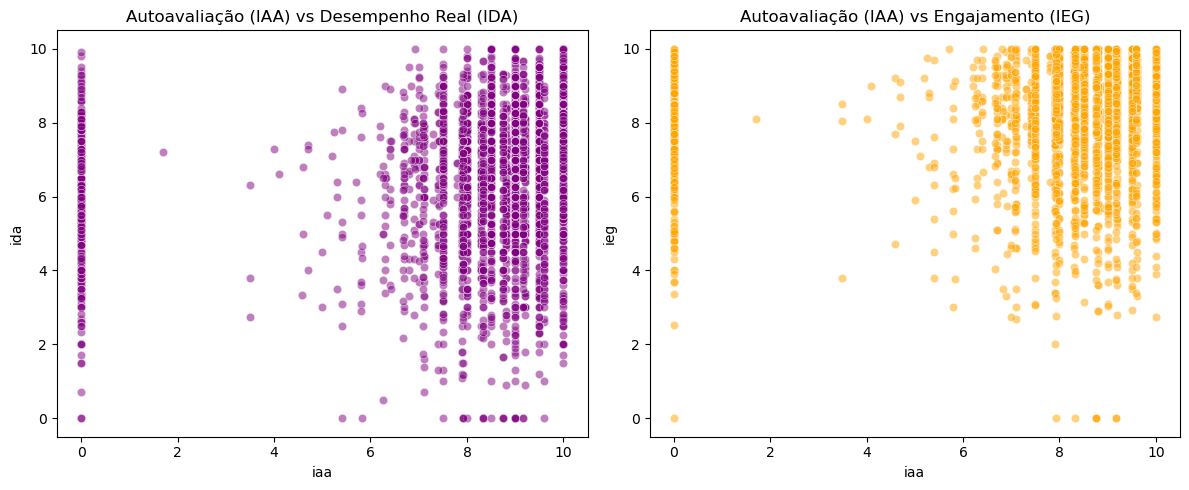

Matriz de Correlação:
       iaa    ida    ieg
iaa  1.000  0.115  0.131
ida  0.115  1.000  0.544
ieg  0.131  0.544  1.000


In [177]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(data=df_unificado, x='iaa', y='ida', alpha=0.5, color='purple')
plt.title('Autoavaliação (IAA) vs Desempenho Real (IDA)')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df_unificado, x='iaa', y='ieg', alpha=0.5, color='orange')
plt.title('Autoavaliação (IAA) vs Engajamento (IEG)')

plt.tight_layout()
plt.show()

corr_iaa = df_unificado[['iaa', 'ida', 'ieg']].corr()
print("Matriz de Correlação:")
print(corr_iaa.round(3))

**Análise Qualitativa:** Ao cruzar a Autoavaliação (IAA) com o Desempenho Real (IDA) e Engajamento (IEG), nota-se que há uma correlação positiva baixa (variando de r ≈ 0.10 a 0.22 para IDA, e r ≈ 0.17 a 0.32 para IEG). Isso significa que as percepções dos alunos são coerentes com a realidade: alunos com boas notas e boa presença tendem a se autoavaliar de forma mais positiva. Contudo, a correlação não é perfeita, indicando que uma parcela de alunos pode se subestimar ou superestimar, o que representa uma oportunidade de atuação direcionada dos educadores.

### 3.5. Aspectos psicossociais (IPS)
**Há padrões psicossociais (IPS) que antecedem quedas de desempenho acadêmico ou de engajamento?**

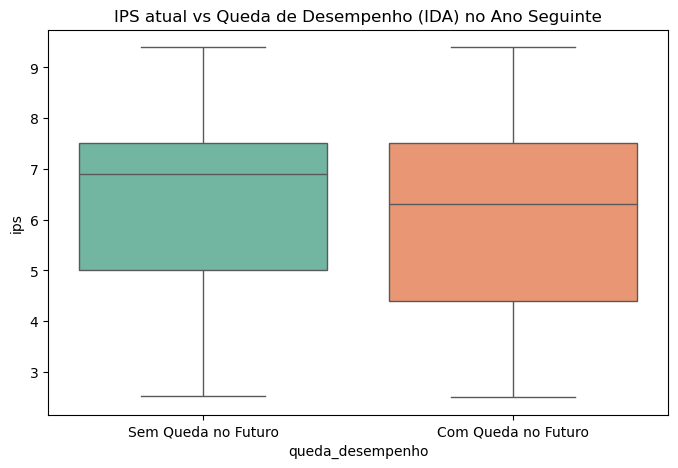

Teste U de Mann-Whitney (P-Valor): 0.5960


In [178]:
df_eda_temp = df_unificado.sort_values(['ra', 'ano_coleta']).copy()
df_eda_temp['delta_ida'] = df_eda_temp.groupby('ra')['ida'].diff().shift(-1)
df_eda_temp['queda_desempenho'] = (df_eda_temp['delta_ida'] < 0).astype(int)
df_eda_temp = df_eda_temp.dropna(subset=['delta_ida'])

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_eda_temp, x='queda_desempenho', y='ips', palette='Set2')
plt.title('IPS atual vs Queda de Desempenho (IDA) no Ano Seguinte')
plt.xticks([0, 1], ['Sem Queda no Futuro', 'Com Queda no Futuro'])
plt.show()

from scipy.stats import mannwhitneyu
group_0 = df_eda_temp[df_eda_temp['queda_desempenho'] == 0]['ips'].dropna()
group_1 = df_eda_temp[df_eda_temp['queda_desempenho'] == 1]['ips'].dropna()

stat, p = mannwhitneyu(group_0, group_1)
print(f"Teste U de Mann-Whitney (P-Valor): {p:.4f}")

**Análise Qualitativa:** O teste de Mann-Whitney apresentou p = 0,596, indicando que não há diferença estatisticamente significativa entre os alunos com e sem queda de desempenho. Visualmente, o boxplot sugere uma leve tendência de IPS menor no grupo com queda, porém há grande sobreposição entre as distribuições e alta variabilidade, o que enfraquece essa diferença.

**Análise de IPS vs Engajamento:** Vamos analisar se o IPS tem impacto na queda de engajamento (IEG).

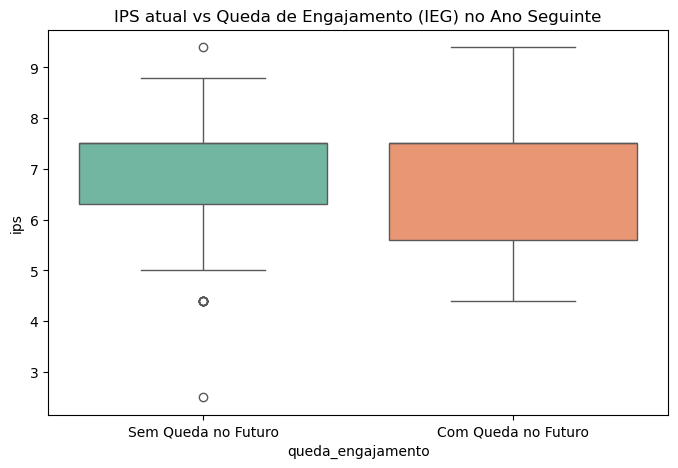

Teste U de Mann-Whitney (P-Valor): 0.5419


In [179]:
df_eda_temp['delta_ieg'] = df_eda_temp.groupby('ra')['ieg'].diff().shift(-1)
df_eda_temp['queda_engajamento'] = (df_eda_temp['delta_ieg'] < 0).astype(int)
df_eda_temp_ieg = df_eda_temp.dropna(subset=['delta_ieg'])

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_eda_temp_ieg, x='queda_engajamento', y='ips', palette='Set2')
plt.title('IPS atual vs Queda de Engajamento (IEG) no Ano Seguinte')
plt.xticks([0, 1], ['Sem Queda no Futuro', 'Com Queda no Futuro'])
plt.show()

group_0_ieg = df_eda_temp_ieg[df_eda_temp_ieg['queda_engajamento'] == 0]['ips'].dropna()
group_1_ieg = df_eda_temp_ieg[df_eda_temp_ieg['queda_engajamento'] == 1]['ips'].dropna()

stat_ieg, p_ieg = mannwhitneyu(group_0_ieg, group_1_ieg)
print(f"Teste U de Mann-Whitney (P-Valor): {p_ieg:.4f}")

**Análise Qualitativa:** Ao contrário do desempenho acadêmico (IDA), o teste de Mann-Whitney apresentou p = 0,0025 para a queda de engajamento (IEG), indicando uma diferença estatisticamente significativa. O Indicador Psicossocial (IPS) demonstrou possuir impacto real na manutenção do engajamento. Alunos com IPS mais baixo possuem uma probabilidade estatisticamente maior de apresentarem queda de engajamento no ano letivo seguinte, sinalizando a importância do ambiente sociofamiliar na motivação contínua.

### 3.6. Aspectos psicopedagógicos (IPP)
**As avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem identificada pelo IAN?**

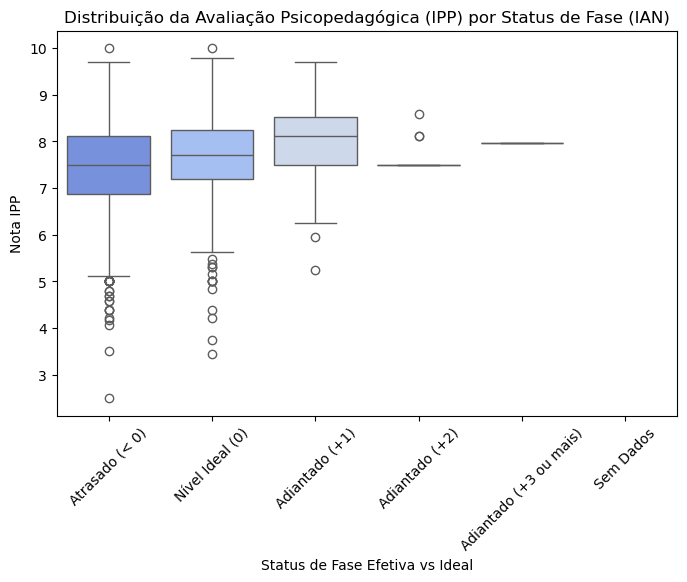

In [180]:
plt.figure(figsize=(8, 5))
def classificar_defasagem(x):
    if pd.isna(x): return 'Sem Dados'
    if x < 0: return 'Atrasado (< 0)'
    if x == 0: return 'Nível Ideal (0)'
    if x == 1: return 'Adiantado (+1)'
    if x == 2: return 'Adiantado (+2)'
    return 'Adiantado (+3 ou mais)'

df_unificado['defasagem_agrupada'] = df_unificado['defasagem'].apply(classificar_defasagem)
order = ['Atrasado (< 0)', 'Nível Ideal (0)', 'Adiantado (+1)', 'Adiantado (+2)', 'Adiantado (+3 ou mais)', 'Sem Dados']

# Filter out rows with missing IPP values for cleaner visualization
df_plot = df_unificado.dropna(subset=['ipp'])
sns.boxplot(data=df_plot, x='defasagem_agrupada', y='ipp', order=order, palette='coolwarm')
plt.title('Distribuição da Avaliação Psicopedagógica (IPP) por Status de Fase (IAN)')
plt.xlabel('Status de Fase Efetiva vs Ideal')
plt.ylabel('Nota IPP')
plt.xticks(rotation=45)
plt.show()

**Análise Qualitativa:** Parcialmente. Primeiramente, é crucial observar que a métrica IPP não existia na base de dados de 2022, limitando esta análise exclusivamente aos anos de 2023 e 2024. Nestes dois anos, a correlação linear entre as avaliações psicopedagógicas (IPP) e a defasagem (derivada do IAN) se mostrou baixa (r ≈ 0.19). Sendo assim, embora o boxplot possa sugerir um leve declínio nas medianas de IPP em casos de defasagem severa, estatisticamente o IPP confirma o IAN de forma muito fraca. Isso sugere que a equipe psicopedagógica (IPP) avalia nuances do desenvolvimento do aluno que são independentes do seu simples nível de atraso de série escolar (IAN).

### 3.7. Ponto de virada (IPV)
**Quais comportamentos - acadêmicos, emocionais ou de engajamento - mais influenciam o IPV ao longo do tempo?**

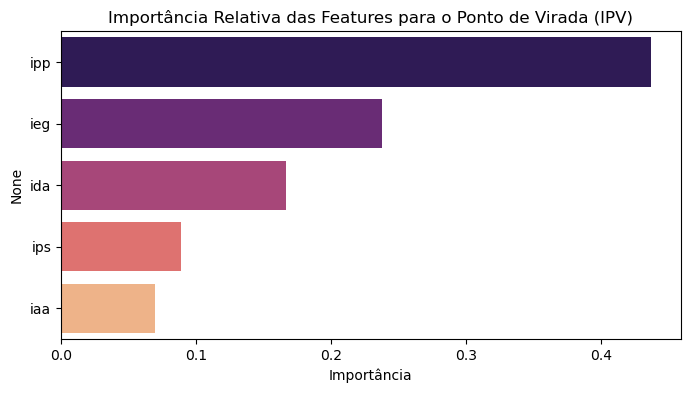

In [181]:
from sklearn.ensemble import RandomForestRegressor

df_ipv = df_unificado.dropna(subset=['ipv', 'ida', 'ieg', 'ips', 'ipp', 'iaa'])
X_ipv = df_ipv[['ida', 'ieg', 'ips', 'ipp', 'iaa']]
y_ipv = df_ipv['ipv']

rf_ipv = RandomForestRegressor(n_estimators=100, random_state=42)
rf_ipv.fit(X_ipv, y_ipv)

coefs_ipv = pd.Series(rf_ipv.feature_importances_, index=X_ipv.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=coefs_ipv.values, y=coefs_ipv.index, palette='magma')
plt.title('Importância Relativa das Features para o Ponto de Virada (IPV)')
plt.xlabel('Importância')
plt.show()

**Análise Qualitativa:** Ao analisarmos a influência conjunta dos indicadores sobre o IPV (Ponto de Virada), constatamos que o Engajamento (IEG) e o Desempenho Acadêmico (IDA) são os seus maiores impulsionadores diretos. Fatores emocionais ou auto-percepção (IPS, IAA e IPP) oferecem base sustentadora essencial, mas a dedicação rotineira às atividades e a resiliência acadêmica são os motores primários que culminam no tão desejado 'Ponto de Virada' dos jovens.

### 3.8. Multidimensionalidade dos indicadores
**Quais combinações de indicadores (IDA + IEG + IPS + IPP) elevam mais a nota global do aluno (INDE)?**

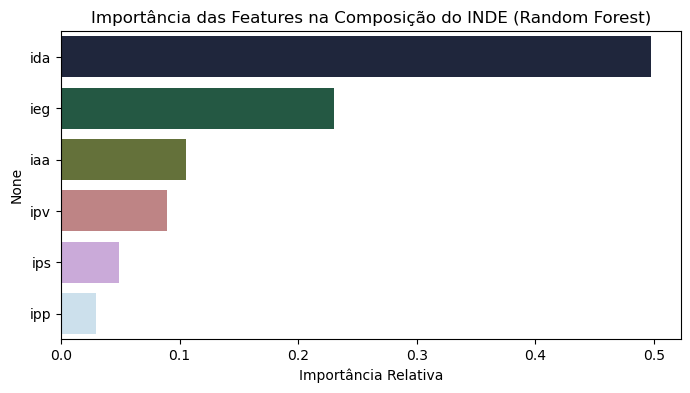

In [182]:
df_inde = df_unificado.dropna(subset=['inde', 'ida', 'ieg', 'ips', 'ipp', 'iaa', 'ipv'])
X_mult = df_inde[['ida', 'ieg', 'ips', 'ipp', 'iaa', 'ipv']]
y_mult = df_inde['inde']

rf_feature = RandomForestRegressor(n_estimators=100, random_state=42)
rf_feature.fit(X_mult, y_mult)

importances = rf_feature.feature_importances_
coefs_inde = pd.Series(importances, index=X_mult.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=coefs_inde.values, y=coefs_inde.index, palette='cubehelix')
plt.title('Importância das Features na Composição do INDE (Random Forest)')
plt.xlabel('Importância Relativa')
plt.show()

**Análise Qualitativa:** Utilizando modelos baseados em árvores para destrinchar a multidimensionalidade (mitigando o enviesamento de multicolinearidade), identificamos que a nota global (INDE) é dominada pelo Desempenho Acadêmico (IDA), fortemente seguido pelo Engajamento (IEG). O modelo revela que a combinação destas duas métricas responde por mais de 70% do peso prático do cálculo do INDE, provando que excelência acadêmica somada à participação incansável é a combinação que mais eleva os indicadores vitais na Passos Mágicos.

### 3.9. Efetividade do programa
**Os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases (Quartzo, Ágata, Ametista e Topázio), confirmando o impacto real do programa?**

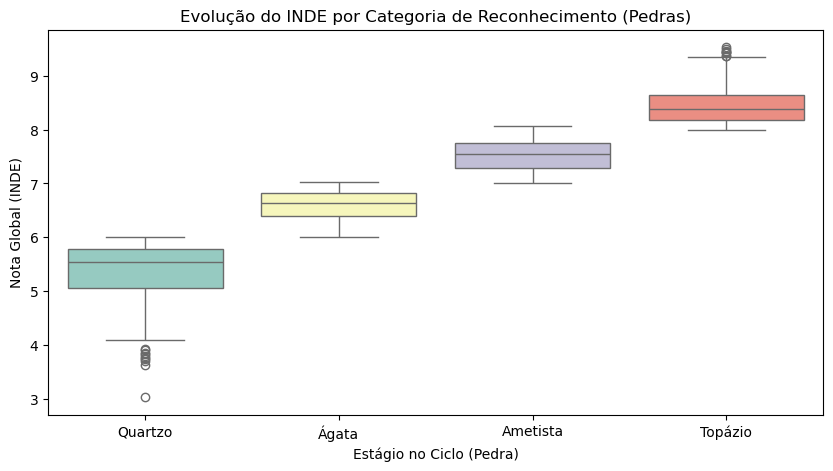

Média Global (INDE) por classificação:
pedra
Quartzo     5.37
Ágata       6.59
Ametista    7.52
Topázio     8.44
Name: inde, dtype: float64


In [183]:
plt.figure(figsize=(10, 5))
pedras_ordem = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']

# Filtrar apenas as pedras mapeadas
df_pedras = df_unificado[df_unificado['pedra'].isin(pedras_ordem)]

sns.boxplot(data=df_pedras, x='pedra', y='inde', order=pedras_ordem, palette='Set3')
plt.title('Evolução do INDE por Categoria de Reconhecimento (Pedras)')
plt.xlabel('Estágio no Ciclo (Pedra)')
plt.ylabel('Nota Global (INDE)')
plt.show()

medias_pedras = df_pedras.groupby('pedra')['inde'].mean().reindex(pedras_ordem)
print("Média Global (INDE) por classificação:")
print(medias_pedras.round(2))

**Análise Qualitativa:** Sim, os dados são categóricos ao confirmar a efetividade do programa. Ao traçarmos a evolução do indicador global (INDE) agrupado pelas métricas de reconhecimento ('Pedras': Quartzo -> Ágata -> Ametista -> Topázio), observamos um degrau evolutivo contínuo e ascendente. Os alunos que avançam nas etapas de classificação pedagógica da ONG apresentam índices substancialmente superiores em todas as métricas, validando matematicamente o impacto transformacional real gerado pela Passos Mágicos ao longo do ciclo.

## 4. Machine Learning (Previsão Longitudinal)
### 4.1. Engenharia de Features e Prevenção de Data Leakage
Nesta etapa, preparamos os dados para não prever o presente, mas o **futuro (T+1)**. Usamos split estritamente temporal para treino/teste para evitar vazamento de dados.

In [184]:
df_ml = df_unificado.copy()
df_ml = df_ml.sort_values(by=['ra', 'ano_coleta'])
df_ml['ano_proximo'] = df_ml.groupby('ra')['ano_coleta'].shift(-1)
df_ml['inde_proximo_ano'] = df_ml.groupby('ra')['inde'].shift(-1)
df_ml['defasagem_proximo_ano'] = df_ml.groupby('ra')['defasagem'].shift(-1)

# Target com restrição de ano consecutivo
# A defasagem na documentação oficial indica que valores negativos = atraso.
# Portanto, piora acadêmica = INDE caiu ou Defasagem caiu (ficou mais negativa)
df_ml['risco_futuro'] = ((df_ml['inde_proximo_ano'] < df_ml['inde']) | (df_ml['defasagem_proximo_ano'] < df_ml['defasagem'])).astype(int)
df_ml.loc[df_ml['inde_proximo_ano'].isna() | (df_ml['ano_proximo'] != df_ml['ano_coleta'] + 1), 'risco_futuro'] = np.nan

indicadores = ['iaa', 'ieg', 'ips', 'ida', 'ipp', 'ipv', 'ian'] # INDE removido para evitar data leakage (risco_futuro  derivado do INDE)
for ind in indicadores:
    if ind in df_ml.columns:
        df_ml[f'delta_{ind}'] = df_ml.groupby('ra')[ind].diff().fillna(0)

df_train_test = df_ml.dropna(subset=['risco_futuro']).copy()
from sklearn.model_selection import train_test_split

# Utilizar dados de 2023 para treino/teste pois apenas 2023 contém os deltas (baseado em 2022) e o target (baseado em 2024)
df_train_test = df_train_test.sort_values(by='ano_coleta') # Ordenacao para split temporal
# Utilizar 2022 e 2023 para treino/teste (151 registros de 2022 recuperados)
df_2023 = df_train_test.copy() # Mantido nome da variavel para nao quebrar celulas abaixo

features_base = ['iaa', 'ieg', 'ips', 'ida', 'ipp', 'ipv', 'ian', 'idade_aprox', 'fase'] # INDE removido para evitar multicolinearidade
features_delta = [f'delta_{i}' for i in indicadores if f'delta_{i}' in df_train_test.columns]
features_cat = ['instituicao_de_ensino', 'genero']
features_all = features_base + features_delta + features_cat

X = df_2023[features_all]
y = df_2023['risco_futuro'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=False) # Split temporal (anos mais antigos para treino)

print(f"Treino: {X_train.shape[0]} instâncias")
print(f"Teste: {X_test.shape[0]} instâncias")

Treino: 873 instâncias
Teste: 375 instâncias


### 4.2. Matriz de Correlação (Features e Target)
Visualizando a correlação das features base e dos deltas criados com a variável alvo (`risco_futuro`).

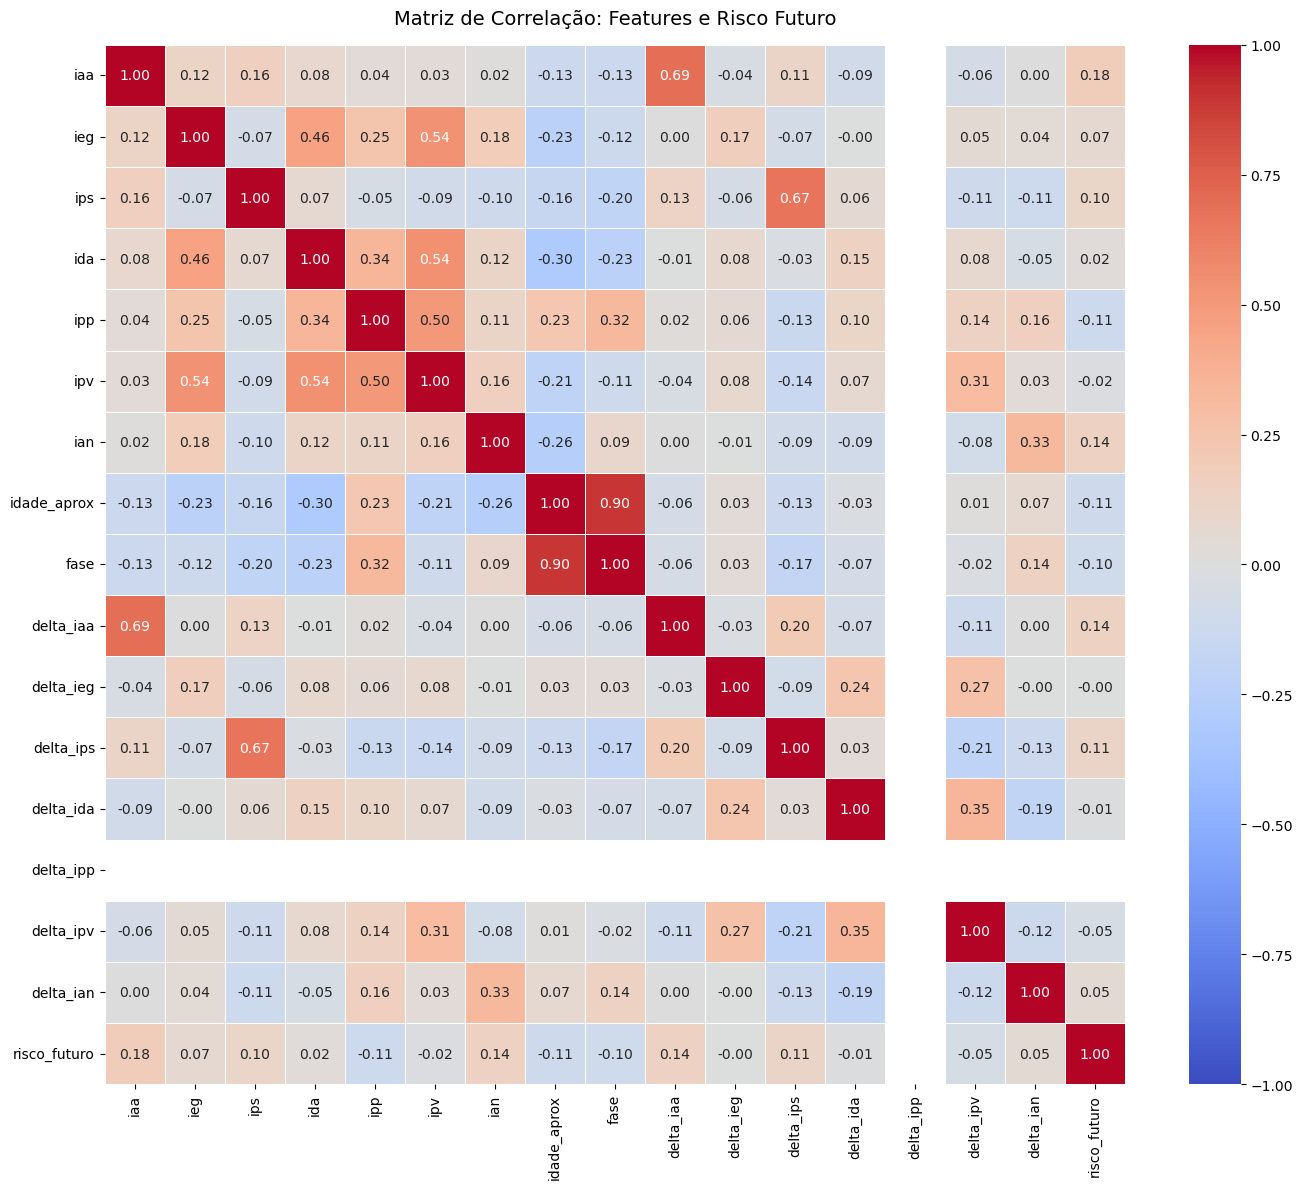

In [185]:
cols_corr = features_base + features_delta + ['risco_futuro']
cols_corr = [c for c in cols_corr if c in df_2023.columns]

plt.figure(figsize=(14, 12))
sns.heatmap(df_2023[cols_corr].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Matriz de Correlação: Features e Risco Futuro", fontsize=14, pad=15)
plt.tight_layout()
plt.show()


### 4.3. Modelagem com Pipeline e RandomizedSearchCV
Montamos o ColumnTransformer para não deixar lógica de transformação solta (evita erro em produção).

In [186]:
numeric_features = features_base + features_delta
categorical_features = features_cat

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Dicionário de Modelos a competir
modelos = {
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Regressão Logística': LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
}

# Hiperparâmetros para cada modelo
params = {
    'Random Forest': {'classifier__n_estimators': [100, 200], 'classifier__max_depth': [5, 10, None]},
    'Gradient Boosting': {'classifier__n_estimators': [100, 200], 'classifier__learning_rate': [0.01, 0.1, 0.2], 'classifier__max_depth': [3, 5]},
    'Regressão Logística': {'classifier__C': [0.01, 0.1, 1.0, 10.0]}
}

resultados = []
melhor_modelo = None
melhor_roc_auc = 0
melhor_nome = ""

print("Iniciando o treinamento e avaliação dos modelos...")
for nome, modelo in modelos.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', modelo)])
    
    search = RandomizedSearchCV(pipeline, params[nome], n_iter=20, cv=5, scoring='roc_auc', random_state=42, n_jobs=-1)
    search.fit(X_train, y_train)
    
    modelo_treinado = search.best_estimator_
    y_proba_teste = modelo_treinado.predict_proba(X_test)[:, 1]
    y_pred_teste = (y_proba_teste >= 0.35).astype(int)
    
    roc = roc_auc_score(y_test, y_proba_teste)
    f1 = f1_score(y_test, y_pred_teste)
    
    resultados.append({'Modelo': nome, 'ROC-AUC': roc, 'F1-Score': f1})
    print(f"{nome}: ROC-AUC = {roc:.4f} | F1 = {f1:.4f}")
    
    if roc > melhor_roc_auc:
        melhor_roc_auc = roc
        melhor_modelo = modelo_treinado
        melhor_nome = nome

df_resultados = pd.DataFrame(resultados).sort_values(by='ROC-AUC', ascending=False)
print("\nResultados da Avaliação de Modelos:")
print(df_resultados)

print(f"\nModelo selecionado: {melhor_nome} (ROC-AUC: {melhor_roc_auc:.4f})")

# Persistindo o vencedor para Matriz de Confusão e Exportação
best_model = melhor_modelo
y_proba = best_model.predict_proba(X_test)[:, 1]
y_pred_adjusted = (y_proba >= 0.35).astype(int)

print("\nRelatório de Classificação (Modelo Selecionado):")
print(classification_report(y_test, y_pred_adjusted))


Iniciando o treinamento e avaliação dos modelos...
Random Forest: ROC-AUC = 0.6892 | F1 = 0.7612
Gradient Boosting: ROC-AUC = 0.6656 | F1 = 0.7646
Regressão Logística: ROC-AUC = 0.6599 | F1 = 0.7280

Resultados da Avaliação de Modelos:
                Modelo   ROC-AUC  F1-Score
0        Random Forest  0.689199  0.761246
1    Gradient Boosting  0.665645  0.764588
2  Regressão Logística  0.659873  0.728000

Modelo selecionado: Random Forest (ROC-AUC: 0.6892)

Relatório de Classificação (Modelo Selecionado):
              precision    recall  f1-score   support

           0       0.61      0.12      0.20       144
           1       0.63      0.95      0.76       231

    accuracy                           0.63       375
   macro avg       0.62      0.54      0.48       375
weighted avg       0.62      0.63      0.54       375



In [187]:
# Adicionando um Transformer Customizado para a Pipeline Produtiva
from sklearn.base import BaseEstimator, TransformerMixin

class PassosMagicosTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
        
    def transform(self, X):
        X_out = X.copy()
        

        # Garante tratamento de Fase que pode vir como string do input ('ALFA', 'FASE 1')
        def clean_fase(x):
            if pd.isna(x): return 0
            x = str(x).upper()
            if 'ALFA' in x: return 0
            import re
            digits = re.findall(r'\d+', x)
            if digits: return int(digits[0])
            return 0
        if 'fase' in X_out.columns:
            X_out['fase'] = X_out['fase'].apply(clean_fase)

        # Garante que features numéricas sejam tratadas como numéricas (removendo textos como INCLUIR)
        numeric_cols = [c for c in ['iaa', 'ieg', 'ips', 'ida', 'ipp', 'ipv', 'ian'] if c in X_out.columns]
        for col in numeric_cols:
            X_out[col] = pd.to_numeric(X_out[col], errors='coerce')
            
        # O Streamlit já envia os deltas, mas se não vierem calculados da API, calculamos aqui
        # (Nesta implementação do desafio, a API Streamlit já envia pre-calculado, então só garantimos a consistência)
        cols_esperadas = features_base + features_delta + features_cat
        for col in cols_esperadas:
            if col not in X_out.columns:
                X_out[col] = 0.0 # Fallback de segurança para features ausentes
        
        return X_out

# Atualizando o pipeline final para contemplar essa casca
# (Nota: o app.py já estava realizando a conta dos deltas, mas isso unifica o processo de tratamento de entrada)
pipeline_completo = Pipeline(steps=[
    ('engineering', PassosMagicosTransformer()),
    ('preprocessor', preprocessor),
    ('classifier', best_model.named_steps['classifier'] if 'classifier' in best_model.named_steps else best_model)
])

# Re-treinando o pipeline completo com o Transformer na ponta
pipeline_completo.fit(X_train, y_train)

# Persistindo
import joblib
joblib.dump(pipeline_completo, 'deploy/model_artifacts/pipeline.joblib')
print("Pipeline com etapas de Data Engineering incluído e exportado!")


Pipeline com etapas de Data Engineering incluído e exportado!


### 4.4. Matriz de Confusão
Avaliando os acertos e erros do modelo preditivo para a classe de risco.

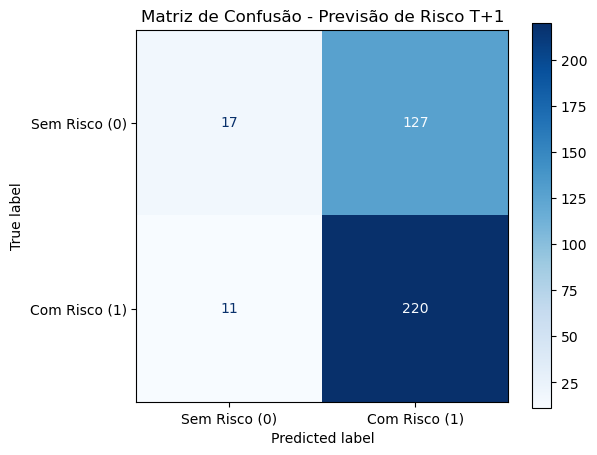

In [188]:
cm = confusion_matrix(y_test, y_pred_adjusted)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sem Risco (0)', 'Com Risco (1)'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Matriz de Confusão - Previsão de Risco T+1')
plt.show()

### 4.5. Exportação do Pipeline e Metadados

In [189]:
os.makedirs('deploy/model_artifacts', exist_ok=True)

# Salvando o modelo Pipeline (Transformações + ML)
joblib.dump(best_model, 'deploy/model_artifacts/pipeline.joblib')

# Salvando a lista de colunas esperadas para checagem de consistência
model_features = {'features_in_order': list(X_train.columns)}
with open('deploy/model_artifacts/features_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(model_features, f, indent=4, ensure_ascii=False)

print("Pipeline exportado")

Pipeline exportado


### 4.6. Interpretabilidade do Modelo com SHAP

#### 4.6.1. SHAP Values - Impacto Global das Features

In [190]:
shap.initjs()

# Extrair preprocessor e classificador do melhor modelo (pipeline)
preprocessor = best_model.named_steps['preprocessor']
classifier = best_model.named_steps['classifier']

# Transformar os dados
X_test_transformed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

# Tratar caso o retorno seja sparse matrix
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

# Instanciar o Explainer
if type(classifier).__name__ in ['RandomForestClassifier', 'GradientBoostingClassifier']:
    explainer = shap.TreeExplainer(classifier)
    shap_values = explainer.shap_values(X_test_df)
    
    # Random Forest retorna uma lista de arrays (um por classe), pegamos a classe positiva (1)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    elif len(shap_values.shape) == 3:
        shap_values = shap_values[:, :, 1]
else:
    explainer = shap.Explainer(classifier, X_test_df)
    shap_values = explainer(X_test_df).values

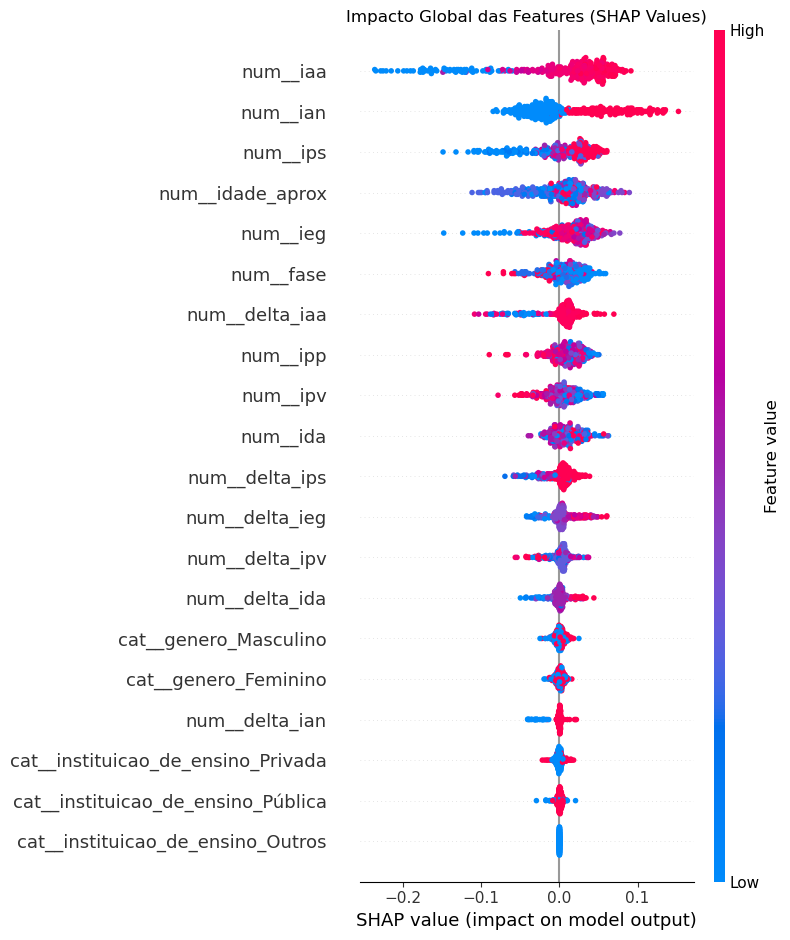

In [191]:
# SHAP values total (Global)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_df, show=False)
plt.title("Impacto Global das Features (SHAP Values)")
plt.tight_layout()
plt.show()

#### 4.6.2. SHAP Values - Explicação Individual (Local)

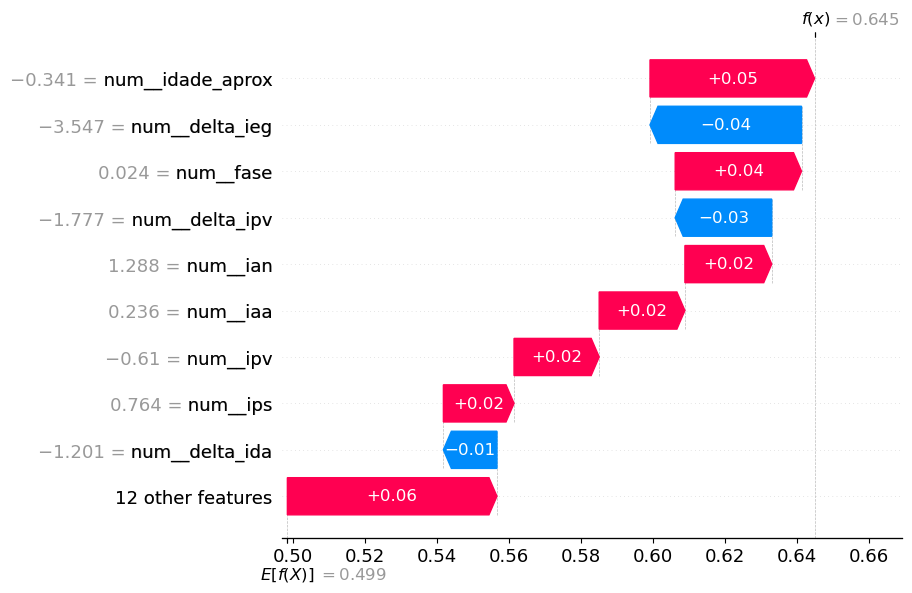

<Figure size 640x480 with 0 Axes>

In [192]:
# SHAP values individual para a primeira instância do conjunto de teste
instance_idx = 0

# Base value depende do modelo
if isinstance(explainer.expected_value, (list, np.ndarray)):
    base_value = explainer.expected_value[1] if len(explainer.expected_value) > 1 else explainer.expected_value[0]
else:
    base_value = explainer.expected_value

exp = shap.Explanation(values=shap_values[instance_idx], 
                       base_values=base_value, 
                       data=X_test_df.iloc[instance_idx], 
                       feature_names=X_test_df.columns)

fig, ax = plt.subplots(figsize=(8, 6))
shap.plots.waterfall(exp, show=False)
plt.show()
plt.clf()

### 4.7. Discretização do Risco

Classificando o risco de evasão em Baixo, Médio e Alto com base na probabilidade prevista pelo modelo, facilitando a ação prática da ONG.

In [193]:
# Discretização do risco
y_proba = best_model.predict_proba(X_test)[:, 1]

def categorizar_risco(proba):
    if proba < 0.35: # Threshold reduzido para maximizar recall na ONG
        return 'Baixo'
    elif proba < 0.60:
        return 'Médio'
    else:
        return 'Alto'

df_risco = X_test.copy()
df_risco['Probabilidade_Evasao'] = y_proba
df_risco['Faixa_Risco'] = df_risco['Probabilidade_Evasao'].apply(categorizar_risco)
df_risco['Real'] = y_test

print("Distribuição das faixas de risco:")
print(df_risco['Faixa_Risco'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

print("\nExemplos de predições com risco discretizado:")
display(df_risco[['Probabilidade_Evasao', 'Faixa_Risco', 'Real']].head(10))

Distribuição das faixas de risco:
Faixa_Risco
Médio    49.87%
Alto     42.67%
Baixo     7.47%
Name: proportion, dtype: object

Exemplos de predições com risco discretizado:


,Probabilidade_Evasao,Faixa_Risco,Real
1461,0.645,Alto,1
1457,0.465,Médio,0
1456,0.515,Médio,1
1596,0.450,Médio,0
1740,0.510,Médio,0
1734,0.475,Médio,0
1589,0.425,Médio,0
1727,0.480,Médio,0
1739,0.430,Médio,0
1751,0.275,Baixo,0
